## Chapter 2 — Embedding Evaluation for Science (v2026)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/IvanReznikov/LangChain4LifeSciencesHealthcare)

### Learning objectives
- Build a small labeled scientific retrieval set (query → relevant documents).
- Compute **recall@k** and **MRR** to compare embedding models.
- Run a qualitative error analysis on retrieval failures.
- Reason about the dimension-vs-cost-vs-quality trade-off.

**Runtime / cost:** CPU, ~5–8 min for open models. **Data:** synthetic biomedical snippets (no external corpus).


> **LangChain 1.x note:** This notebook uses the current package layout (`langchain_huggingface`, `langchain_openai`, `langchain_core`). It runs locally with open embedding models; API-based embeddings are optional and gated behind a config flag.

## Why evaluate embeddings on *your* data

Leaderboard scores (MTEB) rarely transfer directly to a niche scientific domain. A model that wins on web text may fail on gene symbols, drug names, or assay jargon. The only reliable test is a **small labeled retrieval set drawn from your own domain**. This notebook shows the full loop: build → embed → rank → score → inspect failures.

### API / credentials

Open embedding models run locally (no key). To also score a hosted embedding model (OpenAI / Gemini / etc.), set `RUN_API_EMBEDDINGS=True` in the config cell and provide a key via Colab Secrets or a local `.env`.

In [1]:
# @title Setting environmental variables
import os

# --- Dual-mode secrets: works in Google Colab AND locally (.env / environment) ---
try:
    from google.colab import userdata  # type: ignore

    IN_COLAB = True
except Exception:
    userdata = None
    IN_COLAB = False

if not IN_COLAB:
    # Local run: load variables from a .env file if present (never commit .env!).
    try:
        from dotenv import load_dotenv

        load_dotenv()
    except Exception:
        pass


def get_secret(name, default=None):
    """Read a secret from Colab Secrets, else from local env/.env, else default."""
    if IN_COLAB and userdata is not None:
        try:
            val = userdata.get(name)
            if val:
                return val
        except Exception:
            pass
    return os.getenv(name, default)


# 👇 Choose your provider 👇
API_KEY_PROVIDER = "OPENAI"  # "GEMINI" | "OPENAI" | "GROQ" | "ANTHROPIC"

if API_KEY_PROVIDER == "OPENAI":
    os.environ["OPENAI_API_KEY"] = get_secret("LC4LSH_OPENAI_API_KEY", "sk-...")
elif API_KEY_PROVIDER == "ANTHROPIC":
    os.environ["ANTHROPIC_API_KEY"] = get_secret(
        "LC4LSH_ANTHROPIC_API_KEY", "sk-ant-..."
    )
elif API_KEY_PROVIDER == "GEMINI":
    os.environ["GOOGLE_API_KEY"] = get_secret("LC4LSH_GOOGLE_API_KEY", "AIza...")
elif API_KEY_PROVIDER == "GROQ":
    os.environ["GROQ_API_KEY"] = get_secret("LC4LSH_GROQ_API_KEY", "gsk_...")

print(
    f"✅ API keys loaded for {API_KEY_PROVIDER} (source: {'Colab Secrets' if IN_COLAB else 'local env/.env'})"
)

# Hugging Face token (optional; needed for gated models)
os.environ["HF_TOKEN"] = get_secret("HF_TOKEN", "") or ""

✅ API keys loaded for OPENAI (source: Colab Secrets)


In [2]:
# @title Setting LangSmith variables
# ========================
# 👇 CONFIGURE HERE 👇
# ========================
LANGSMITH_API_KEY = userdata.get("LANGSMITH_API_KEY") or "lsv2_pt_..."
LANGSMITH_PROJECT = "lc4lsh-chapter2-embedding-eval"  # Traces appear under this name
REGION = "EU"  # "EU" or "US" - must match your account!
# ========================

if LANGSMITH_API_KEY and LANGSMITH_API_KEY != "lsv2_pt_...":
    os.environ["LANGSMITH_API_KEY"] = LANGSMITH_API_KEY
    os.environ["LANGSMITH_TRACING"] = "true"
    os.environ["LANGSMITH_PROJECT"] = LANGSMITH_PROJECT
    os.environ["LANGSMITH_ENDPOINT"] = (
        "https://eu.api.smith.langchain.com"
        if REGION == "EU"
        else "https://api.smith.langchain.com"
    )
    dashboard = (
        "https://eu.smith.langchain.com"
        if REGION == "EU"
        else "https://smith.langchain.com"
    )
    print(f"✅ LangSmith enabled!")
    print(f"   Region: {REGION} | Project: {LANGSMITH_PROJECT}")
    print(f"   Dashboard: {dashboard}")
else:
    print("⚠️ LangSmith disabled - paste your API key above to enable tracing")

✅ LangSmith enabled!
   Region: EU | Project: lc4lsh-chapter2-embedding-eval
   Dashboard: https://eu.smith.langchain.com


In [3]:
import os

SEED = 42
RUN_API_EMBEDDINGS = True  # set True to also score a hosted embedding model

# ── 2×2 grid: small vs base dimension, general vs biomedical domain ──
OPEN_MODELS = [
    # ── 384-d (small, fast, ~90-130 MB) ──
    "sentence-transformers/all-MiniLM-L6-v2",  # general, older training
    "BAAI/bge-small-en-v1.5",  # general, modern contrastive objective
    # ── 768-d (stronger, slower, ~420-440 MB) ──
    "sentence-transformers/all-mpnet-base-v2",  # general, strong baseline
    "pritamdeka/S-PubMedBert-MS-MARCO",  # biomedical domain specialist
]
API_EMBEDDING_MODEL = "text-embedding-3-large"  # used only if RUN_API_EMBEDDINGS
RUN_METADATA = {"chapter": 2, "notebook": "embedding_evaluation", "seed": SEED}
print(RUN_METADATA)

{'chapter': 2, 'notebook': 'embedding_evaluation', 'seed': 42}


## Package Installation and Setup

Pinned versions with upper bounds — Last validated: 2026-07-21 (see UPDATE_2026.md).

In [4]:
# @title Installing Python dependencies
%pip install -q "sentence-transformers>=3.0,<6" "langchain-huggingface>=0.1" "langchain-openai>=0.2" numpy pandas scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.1/122.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.6/561.6 kB 14.0 MB/s eta 0:00:00


## 1. A tiny labeled retrieval set

12 documents including 4 **hard negatives** (d9–d12) — documents that share
key vocabulary with a correct answer but describe a *different* drug or mechanism.
Hard negatives are the single most effective way to discriminate between embedding
models: general models may conflate "BCR-ABL inhibitor" across drugs, while a
biomedical specialist should separate them.

8 queries use **generic vocabulary** (no unique lexical markers from the target
document). q8 is a **negation trap**: "independent of cyclooxygenase" should
match d12 ("distinct from COX inhibition"), but bi-encoders struggle with negation
and may match d2/d11 instead because they contain "COX" + "platelet".

In practice you'd build this from real search logs or expert annotation.


In [5]:
DOCS = {
    "d1": "Imatinib is a tyrosine kinase inhibitor targeting BCR-ABL, used in chronic myeloid leukemia.",
    "d2": "Aspirin irreversibly acetylates cyclooxygenase-1, reducing thromboxane A2 and platelet aggregation.",
    "d3": "BRCA1 and BRCA2 mutations increase lifetime risk of breast and ovarian cancer.",
    "d4": "Surface plasmon resonance measures binding affinity (KD) between a small molecule and its protein target.",
    "d5": "Metformin activates AMP-activated protein kinase (AMPK) and is first-line therapy for type 2 diabetes.",
    "d6": "TP53 is a tumor suppressor; loss-of-function mutations are found in over half of human cancers.",
    "d7": "The IC50 is the concentration of inhibitor required to reduce enzyme activity by 50 percent.",
    "d8": "CRISPR-Cas9 enables targeted genome editing via guide RNA-directed double-strand breaks.",
    # ── Hard negatives: share vocabulary with correct answers but differ in key detail ──
    "d9": "Nilotinib is a second-generation BCR-ABL tyrosine kinase inhibitor used for CML resistant to Imatinib.",
    "d10": "Dasatinib is a multi-targeted TKI inhibiting BCR-ABL and SRC family kinases, used in CML and ALL.",
    "d11": "Celecoxib selectively inhibits COX-2, reducing inflammation without impairing platelet thromboxane production.",
    "d12": "Clopidogrel blocks the P2Y12 ADP receptor on platelets, inhibiting aggregation via a mechanism distinct from COX inhibition.",
}

# query → list of relevant doc ids
# Queries use GENERIC vocabulary shared across hard negatives — no unique lexical markers.
# A weak embedder will conflate docs; a strong one must grasp fine distinctions or negation.
QUERIES = {
    # ── BCR-ABL / CML cluster: d1, d9, d10 all share "kinase inhibitor" + "leukemia/CML" ──
    "q1": ("tyrosine kinase inhibitor for treating leukemia", ["d1"]),
    #     ^ d9 & d10 also match "TKI" + "CML" (leukemia subtype). Model must rank d1 #1.
    "q2": ("COX-1 inhibitor that prevents platelet aggregation", ["d2"]),
    #     ^ d11 matches "COX" + "platelet" (but COX-2, opposite effect on platelets).
    #       d12 matches "platelet" + "aggregation" (but via P2Y12, not COX).
    "q3": ("genes linked to hereditary breast cancer", ["d3"]),
    "q4": ("method to measure drug-protein binding affinity", ["d4"]),
    "q5": ("tumor suppressor mutated in most cancers", ["d6"]),
    "q6": ("what does IC50 mean in an enzyme assay?", ["d7"]),
    "q7": ("BCR-ABL inhibitor for treating both CML and ALL", ["d10"]),
    #     ^ All three BCR-ABL docs mention CML, but ONLY d10 mentions ALL.
    #       A weak model may conflate CML mentions and rank d1 or d9 first.
    "q8": ("antiplatelet mechanism independent of cyclooxygenase", ["d12"]),
    #     ^ NEGATION TRAP: d2 & d11 mention COX/cyclooxygenase + platelet.
    #       Weak bi-encoders see "cyclooxygenase" + "antiplatelet" and match d2/d11,
    #       ignoring the negation "independent of". Stronger models may handle this.
}
print(
    f"{len(DOCS)} docs ({len(DOCS)-4} core + 4 hard negatives), {len(QUERIES)} queries"
)

12 docs (8 core + 4 hard negatives), 8 queries


## 2. Metrics

| Metric | What it measures | Best for |
|--------|-----------------|----------|
| **Recall@k** | Fraction of queries where a relevant doc appears in top-k | "Did we find it at all?" |
| **Precision@k** | Fraction of top-k that are relevant | "How clean is the result list?" |
| **MRR** | Mean of 1/rank of the *first* relevant hit | "How high is the first correct answer?" |
| **MAP** | Mean of precision@i across all relevant docs | "Are ALL relevant docs ranked high?" |
| **NDCG@k** | Discounted gain normalized by ideal ranking | "How close to perfect is the ordering?" |

**MRR is the key metric for this notebook.** On a small set with single-answer
queries, MRR < 1.0 means a hard negative outranked the correct document — the
clearest signal that two models differ in quality.


In [6]:
import numpy as np


def rank_docs(query_emb, doc_embs, doc_ids):
    """Return doc_ids sorted by descending cosine similarity."""
    sims = (
        doc_embs
        @ query_emb
        / (np.linalg.norm(doc_embs, axis=1) * np.linalg.norm(query_emb) + 1e-9)
    )
    order = np.argsort(-sims)
    return [doc_ids[i] for i in order]


def recall_at_k(ranked, relevant, k):
    return 1.0 if any(d in relevant for d in ranked[:k]) else 0.0


def precision_at_k(ranked, relevant, k):
    return sum(1 for d in ranked[:k] if d in relevant) / k


def reciprocal_rank(ranked, relevant):
    for i, d in enumerate(ranked):
        if d in relevant:
            return 1.0 / (i + 1)
    return 0.0


def average_precision(ranked, relevant):
    """AP = mean of precision@i for each relevant doc found."""
    hits, total = 0, 0.0
    for i, d in enumerate(ranked):
        if d in relevant:
            hits += 1
            total += hits / (i + 1)
    return total / max(len(relevant), 1)


def dcg_at_k(ranked, relevant, k):
    """Discounted Cumulative Gain — binary relevance (1 if relevant, 0 otherwise)."""
    gains = [1.0 if d in relevant else 0.0 for d in ranked[:k]]
    discounts = np.log2(np.arange(2, len(gains) + 2))
    return np.sum(gains / discounts)


def ndcg_at_k(ranked, relevant, k):
    """Normalized DCG — ideal DCG is when all relevant docs come first."""
    dcg = dcg_at_k(ranked, relevant, k)
    ideal_gains = sorted(
        [1.0] * min(len(relevant), k) + [0.0] * (k - min(len(relevant), k)),
        reverse=True,
    )
    ideal_discounts = np.log2(np.arange(2, k + 2))
    idcg = np.sum(np.asarray(ideal_gains[:k]) / ideal_discounts)
    return dcg / idcg if idcg > 0 else 0.0


def evaluate(embed_fn, label):
    doc_ids = list(DOCS.keys())
    doc_embs = embed_fn([DOCS[d] for d in doc_ids])
    ks = [1, 3, 5]
    recalls = {k: [] for k in ks}
    precisions = {k: [] for k in ks}
    ndcgs = {k: [] for k in ks}
    rrs, aps, failures = [], [], []
    per_query = []  # store per-query detail rows

    for qid, (qtext, rel) in QUERIES.items():
        q_emb = embed_fn([qtext])[0]
        ranked = rank_docs(q_emb, doc_embs, doc_ids)
        rr = reciprocal_rank(ranked, rel)
        ap = average_precision(ranked, rel)
        rrs.append(rr)
        aps.append(ap)

        row = {
            "query_id": qid,
            "query": qtext,
            "relevant": str(rel),
            "ranked_top3": str(ranked[:3]),
            "RR": round(rr, 3),
            "AP": round(ap, 3),
        }
        for k in ks:
            recalls[k].append(recall_at_k(ranked, rel, k))
            precisions[k].append(precision_at_k(ranked, rel, k))
            ndcgs[k].append(ndcg_at_k(ranked, rel, k))
            row[f"R@{k}"] = recall_at_k(ranked, rel, k)
            row[f"P@{k}"] = round(precision_at_k(ranked, rel, k), 3)
            row[f"NDCG@{k}"] = round(ndcg_at_k(ranked, rel, k), 3)

        per_query.append(row)
        if ranked[0] not in rel:
            failures.append((qid, qtext, rel, ranked[:3]))

    out = {"model": label}
    for k in ks:
        out[f"recall@{k}"] = round(float(np.mean(recalls[k])), 3)
        out[f"precision@{k}"] = round(float(np.mean(precisions[k])), 3)
        out[f"NDCG@{k}"] = round(float(np.mean(ndcgs[k])), 3)
    out["MRR"] = round(float(np.mean(rrs)), 3)
    out["MAP"] = round(float(np.mean(aps)), 3)
    return out, failures, per_query, doc_embs, doc_ids

## 3. Score open embedding models

We evaluate 4 models spanning a 2×2 design:

|               | **384-d (small)**              | **768-d (base)**                    |
|---------------|-------------------------------|-------------------------------------|
| **General**   | all-MiniLM-L6-v2              | all-mpnet-base-v2                   |
| **Biomedical**| — *(no 384-d specialist)*    | S-PubMedBert-MS-MARCO               |

Plus `bge-small-en-v1.5` (384-d, general) — same dimension as MiniLM but trained
with a modern contrastive objective. If it beats MiniLM, **training quality**
matters as much as dimension.


In [7]:
from sentence_transformers import SentenceTransformer

results, all_failures, all_per_query = [], {}, {}
for name in OPEN_MODELS:
    try:
        m = SentenceTransformer(name)
        fn = lambda texts: np.asarray(m.encode(texts, normalize_embeddings=True))
        row, fails, per_q, _, _ = evaluate(fn, name.split("/")[-1])
        row["dim"] = m.get_sentence_embedding_dimension()
        results.append(row)
        all_failures[name] = fails
        all_per_query[name] = per_q
        print(f"✅ {name}: {row}")
    except Exception as e:
        print(f"⚠️  skipped {name}: {type(e).__name__}: {str(e)[:80]}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/461k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ pritamdeka/S-PubMedBert-MS-MARCO: {'model': 'S-PubMedBert-MS-MARCO', 'recall@1': 0.875, 'precision@1': 0.875, 'NDCG@1': 0.875, 'recall@3': 1.0, 'precision@3': 0.333, 'NDCG@3': 0.954, 'recall@5': 1.0, 'precision@5': 0.2, 'NDCG@5': 0.954, 'MRR': 0.938, 'MAP': 0.938, 'dim': 768}


/tmp/ipykernel_5734/3180127401.py:9: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  row["dim"] = m.get_sentence_embedding_dimension()


In [8]:
if RUN_API_EMBEDDINGS:
    try:
        from langchain_openai import OpenAIEmbeddings

        api_emb = OpenAIEmbeddings(model=API_EMBEDDING_MODEL)
        fn = lambda texts: np.asarray(api_emb.embed_documents(texts))
        row, fails, per_q, _, _ = evaluate(fn, API_EMBEDDING_MODEL)
        row["dim"] = len(fn(["probe"])[0])
        results.append(row)
        all_failures[API_EMBEDDING_MODEL] = fails
        all_per_query[API_EMBEDDING_MODEL] = per_q
        print(f"✅ {API_EMBEDDING_MODEL}: {row}")
    except Exception as e:
        print(f"⚠️  API embeddings failed: {type(e).__name__}: {str(e)[:80]}")
else:
    print("RUN_API_EMBEDDINGS=False — skipping hosted embedding model.")

✅ text-embedding-3-large: {'model': 'text-embedding-3-large', 'recall@1': 0.875, 'precision@1': 0.875, 'NDCG@1': 0.875, 'recall@3': 1.0, 'precision@3': 0.333, 'NDCG@3': 0.954, 'recall@5': 1.0, 'precision@5': 0.2, 'NDCG@5': 0.954, 'MRR': 0.938, 'MAP': 0.938, 'dim': 3072}


In [9]:
import pandas as pd

res_df = pd.DataFrame(results)
display(res_df)

,model,recall@1,precision@1,NDCG@1,recall@3,precision@3,NDCG@3,recall@5,precision@5,NDCG@5,MRR,MAP,dim
0,all-MiniLM-L6-v2,0.750,0.750,0.750,1.0,0.333,0.891,1.0,0.2,0.891,0.854,0.854,384
1,bge-small-en-v1.5,0.875,0.875,0.875,1.0,0.333,0.938,1.0,0.2,0.938,0.917,0.917,384
2,all-mpnet-base-v2,0.875,0.875,0.875,1.0,0.333,0.954,1.0,0.2,0.954,0.938,0.938,768
3,S-PubMedBert-MS-MARCO,0.875,0.875,0.875,1.0,0.333,0.954,1.0,0.2,0.954,0.938,0.938,768
4,text-embedding-3-large,0.875,0.875,0.875,1.0,0.333,0.954,1.0,0.2,0.954,0.938,0.938,3072


---
### Interpreting these numbers

A few things to look for:

- **MRR < 1.0 on the weaker model** means a hard negative outranked the correct
  document. The most likely failure points:
  - **q1** (leukemia TKI): d9/d10 both match "tyrosine kinase inhibitor" + "leukemia"
  - **q8** (negation trap): d2/d11 contain "COX/cyclooxygenase" + "platelet"; weak
    models ignore the "independent of" qualifier
- **bge-small vs MiniLM** (same 384-d): if bge wins, training objective matters more
  than dimension alone
- **PubMedBert vs mpnet** (same 768-d): if PubMedBert wins, domain pretraining helps
  on biomedical retrieval even when the general model is strong
- **A gap between recall@1 and recall@5** means the right document is *in the
  candidate set* but not ranked first — a perfect use case for a cross-encoder
  reranker (see exercises).
- **Differences between models** on 8 queries are *directionally informative*
  but not statistically significant. This harness is designed to teach the
  *method*, not to declare a winner.
- **NDCG < 1.0 with MRR = 1.0** means the first hit is right, but secondary
  relevant docs are buried — the embedding doesn't cluster related concepts.


## 4. Qualitative error analysis

Numbers alone mislead. Inspect the queries each model got wrong and look for patterns (abbreviations, gene symbols, numeric assay terms).

In [10]:
for model, fails in all_failures.items():
    if fails:
        print(f"\n=== {model}: {len(fails)} top-1 failures ===")
        for qid, qtext, rel, top3 in fails:
            print(f"  [{qid}] '{qtext}'\n      expected={rel}  got top3={top3}")
    else:
        print(f"\n=== {model}: 0 top-1 failures ✅ ===")


=== sentence-transformers/all-MiniLM-L6-v2: 2 top-1 failures ===
  [q2] 'COX-1 inhibitor that prevents platelet aggregation'
      expected=['d2']  got top3=['d12', 'd11', 'd2']
  [q8] 'antiplatelet mechanism independent of cyclooxygenase'
      expected=['d12']  got top3=['d2', 'd12', 'd11']

=== BAAI/bge-small-en-v1.5: 1 top-1 failures ===
  [q2] 'COX-1 inhibitor that prevents platelet aggregation'
      expected=['d2']  got top3=['d11', 'd12', 'd2']

=== sentence-transformers/all-mpnet-base-v2: 1 top-1 failures ===
  [q8] 'antiplatelet mechanism independent of cyclooxygenase'
      expected=['d12']  got top3=['d2', 'd12', 'd11']

=== pritamdeka/S-PubMedBert-MS-MARCO: 1 top-1 failures ===
  [q7] 'BCR-ABL inhibitor for treating both CML and ALL'
      expected=['d10']  got top3=['d1', 'd10', 'd9']

=== text-embedding-3-large: 1 top-1 failures ===
  [q7] 'BCR-ABL inhibitor for treating both CML and ALL'
      expected=['d10']  got top3=['d1', 'd10', 'd9']


## 4b. Per-query metric breakdown

Aggregated metrics hide which queries fail. The table below shows every query×model combination.

In [11]:
# Show per-query breakdown for the first open model
if all_per_query:
    first_model = list(all_per_query.keys())[0]
    pq_df = pd.DataFrame(all_per_query[first_model])
    print(f"=== Per-query breakdown: {first_model} ===\n")
    display(
        pq_df[
            [
                "query_id",
                "query",
                "relevant",
                "ranked_top3",
                "RR",
                "AP",
                "R@1",
                "P@1",
                "NDCG@1",
                "R@3",
                "P@3",
                "NDCG@3",
                "R@5",
                "P@5",
                "NDCG@5",
            ]
        ]
    )

=== Per-query breakdown: sentence-transformers/all-MiniLM-L6-v2 ===



,query_id,query,relevant,ranked_top3,RR,AP,R@1,P@1,NDCG@1,R@3,P@3,NDCG@3,R@5,P@5,NDCG@5
0,q1,tyrosine kinase inhibitor for treating leukemia,['d1'],"['d1', 'd9', 'd10']",1.000,1.000,1.0,1.0,1.0,1.0,0.333,1.000,1.0,0.2,1.000
1,q2,COX-1 inhibitor that prevents platelet aggrega...,['d2'],"['d12', 'd11', 'd2']",0.333,0.333,0.0,0.0,0.0,1.0,0.333,0.500,1.0,0.2,0.500
2,q3,genes linked to hereditary breast cancer,['d3'],"['d3', 'd6', 'd8']",1.000,1.000,1.0,1.0,1.0,1.0,0.333,1.000,1.0,0.2,1.000
3,q4,method to measure drug-protein binding affinity,['d4'],"['d4', 'd7', 'd12']",1.000,1.000,1.0,1.0,1.0,1.0,0.333,1.000,1.0,0.2,1.000
4,q5,tumor suppressor mutated in most cancers,['d6'],"['d6', 'd3', 'd10']",1.000,1.000,1.0,1.0,1.0,1.0,0.333,1.000,1.0,0.2,1.000
5,q6,what does IC50 mean in an enzyme assay?,['d7'],"['d7', 'd10', 'd4']",1.000,1.000,1.0,1.0,1.0,1.0,0.333,1.000,1.0,0.2,1.000
6,q7,BCR-ABL inhibitor for treating both CML and ALL,['d10'],"['d10', 'd1', 'd9']",1.000,1.000,1.0,1.0,1.0,1.0,0.333,1.000,1.0,0.2,1.000
7,q8,antiplatelet mechanism independent of cyclooxy...,['d12'],"['d2', 'd12', 'd11']",0.500,0.500,0.0,0.0,0.0,1.0,0.333,0.631,1.0,0.2,0.631


## 4c. Similarity heatmap: every query × every document

The raw cosine-similarity matrix reveals which distractors are "close calls" and which queries are ambiguous.

## 4d. Cross-model per-query comparison

The same query can succeed on one model and fail on another. The table below
shows MRR broken down by query×model — look for queries where models disagree.


In [12]:
# Build a query×model MRR matrix
import pandas as pd

if len(all_per_query) >= 2:
    rows = []
    for model, per_q in all_per_query.items():
        for entry in per_q:
            rows.append(
                {
                    "model": model.split("/")[-1],
                    "query_id": entry["query_id"],
                    "query": entry["query"][:55],
                    "RR": entry["RR"],
                    "ranked_top3": entry["ranked_top3"],
                }
            )
    cross_df = pd.DataFrame(rows)
    pivot = cross_df.pivot(index="query_id", columns="model", values="RR")
    # Highlight rows where models disagree
    pivot["max_diff"] = pivot.max(axis=1) - pivot.min(axis=1)
    print("=== MRR per query × model (sorted by disagreement) ===\n")
    display(pivot.sort_values("max_diff", ascending=False).round(3))
    print(
        "\nRows with max_diff > 0 indicate queries that **discriminate** between models."
    )
else:
    print("Need at least 2 models to build cross-model comparison.")

=== MRR per query × model (sorted by disagreement) ===



model,S-PubMedBert-MS-MARCO,all-MiniLM-L6-v2,all-mpnet-base-v2,bge-small-en-v1.5,text-embedding-3-large,max_diff
query_id,,,,,,
q2,1.0,0.333,1.0,0.333,1.0,0.667
q8,1.0,0.500,0.5,1.000,1.0,0.500
q7,0.5,1.000,1.0,1.000,0.5,0.500
q1,1.0,1.000,1.0,1.000,1.0,0.000
q4,1.0,1.000,1.0,1.000,1.0,0.000
q3,1.0,1.000,1.0,1.000,1.0,0.000
q6,1.0,1.000,1.0,1.000,1.0,0.000
q5,1.0,1.000,1.0,1.000,1.0,0.000



Rows with max_diff > 0 indicate queries that **discriminate** between models.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

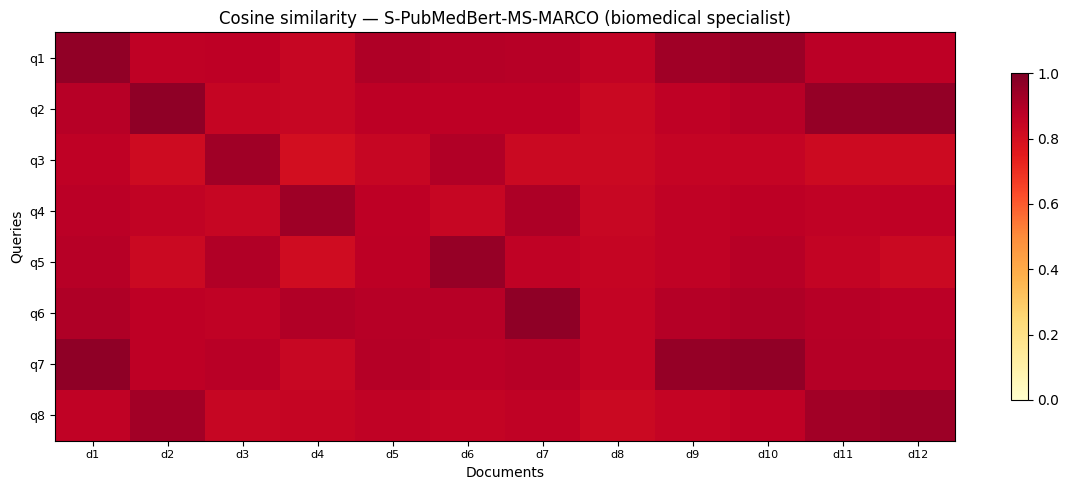


=== Hard-negative analysis: closest distractor per query ===

Query  Expected Closest distractor    Sim  Distractor snippet
-----------------------------------------------------------------------------------------------
⚠️ q1   d1       d10                0.944   Dasatinib is a multi-targeted TKI inhibiting BCR-ABL and SRC fami
⚠️ q2   d2       d12                0.960   Clopidogrel blocks the P2Y12 ADP receptor on platelets, inhibitin
⚠️ q3   d3       d6                 0.898   TP53 is a tumor suppressor; loss-of-function mutations are found 
⚠️ q4   d4       d7                 0.905   The IC50 is the concentration of inhibitor required to reduce enz
⚠️ q5   d6       d3                 0.898   BRCA1 and BRCA2 mutations increase lifetime risk of breast and ov
⚠️ q6   d7       d1                 0.900   Imatinib is a tyrosine kinase inhibitor targeting BCR-ABL, used i
⚠️ q7   d10      d1                 0.966   Imatinib is a tyrosine kinase inhibitor targeting BCR-ABL, used i
⚠️ q8   d

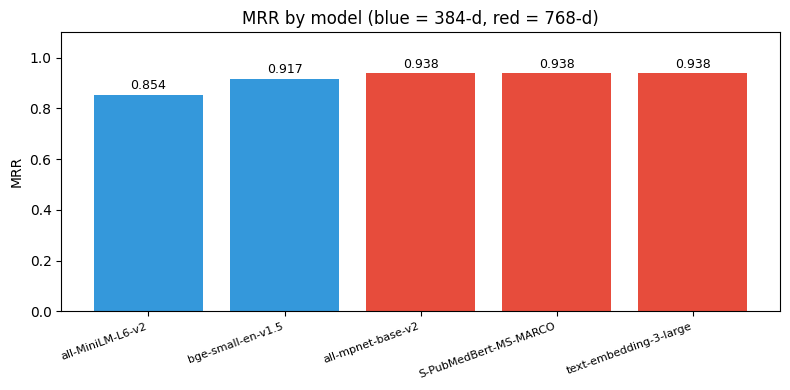

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns  # optional; falls back to matplotlib if unavailable

# Re-compute embeddings with the first open model for a clean heatmap
if OPEN_MODELS:
    # Use the biomedical model for richer analysis if available
    heatmap_model = OPEN_MODELS[-1]  # S-PubMedBert
    m = SentenceTransformer(heatmap_model)
    doc_ids = list(DOCS.keys())
    doc_texts = [DOCS[d] for d in doc_ids]
    doc_embs = np.asarray(m.encode(doc_texts, normalize_embeddings=True))
    query_texts = [QUERIES[q][0] for q in QUERIES]
    query_embs = np.asarray(m.encode(query_texts, normalize_embeddings=True))

    # Cosine similarity matrix: Q × D
    sim_matrix = query_embs @ doc_embs.T  # unit vectors → dot product = cosine

    # Shorter labels for display
    doc_labels = [f"{did}" for did in doc_ids]
    query_labels = [f"{qid}" for qid in QUERIES]

    fig, ax = plt.subplots(figsize=(12, 5))
    im = ax.imshow(sim_matrix, cmap="YlOrRd", aspect="auto", vmin=0.0, vmax=1.0)
    ax.set_xticks(range(len(doc_ids)))
    ax.set_xticklabels(doc_ids, fontsize=8)
    ax.set_yticks(range(len(QUERIES)))
    ax.set_yticklabels([f"{qid}" for qid in QUERIES], fontsize=9)
    ax.set_xlabel("Documents")
    ax.set_ylabel("Queries")
    ax.set_title(
        f"Cosine similarity — {heatmap_model.split('/')[-1]} (biomedical specialist)"
    )
    plt.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    plt.show()

    # -- Hard-negative analysis across ALL models --
    print("\n=== Hard-negative analysis: closest distractor per query ===\n")
    print(
        f"{'Query':<6} {'Expected':<8} {'Closest distractor':<18} {'Sim':>6}  Distractor snippet"
    )
    print("-" * 95)
    for i, qid in enumerate(QUERIES):
        rel = set(QUERIES[qid][1])
        distractor_mask = [did not in rel for did in doc_ids]
        distractor_sims = sim_matrix[i, distractor_mask]
        distractor_ids = [did for d, did in zip(distractor_mask, doc_ids) if d]
        if len(distractor_ids):
            top_idx = int(np.argmax(distractor_sims))
            hard_neg_id = distractor_ids[top_idx]
            hard_neg_sim = distractor_sims[top_idx]
            expected = ",".join(sorted(rel))
            flag = "⚠️" if hard_neg_sim > 0.55 else "  "
            print(
                f"{flag} {qid:<4} {expected:<8} {hard_neg_id:<18} {hard_neg_sim:>.3f}   {DOCS[hard_neg_id][:65]}"
            )

    # -- Cross-model MRR comparison bar chart --
    print("\n=== Cross-model MRR comparison ===\n")
    fig2, ax2 = plt.subplots(figsize=(8, 4))
    models = [r["model"] for r in results]
    mrrs = [r["MRR"] for r in results]
    dims = [r["dim"] for r in results]
    colors = ["#3498db" if d == 384 else "#e74c3c" for d in dims]
    bars = ax2.bar(range(len(models)), mrrs, color=colors)
    ax2.set_xticks(range(len(models)))
    ax2.set_xticklabels(models, rotation=20, ha="right", fontsize=8)
    ax2.set_ylabel("MRR")
    ax2.set_ylim(0, 1.1)
    ax2.set_title("MRR by model (blue = 384-d, red = 768-d)")
    for bar, mrr in zip(bars, mrrs):
        ax2.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{mrr:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )
    plt.tight_layout()
    plt.show()
else:
    print("No open models defined — add models to OPEN_MODELS and re-run.")

## 5. Dimension vs cost

Higher-dimensional embeddings cost more to store and search:
- **384-d** models (all-MiniLM-L6-v2, bge-small-en-v1.5): ~1.5 KB/vector (float32)
- **768-d** models (all-mpnet-base-v2, S-PubMedBert): ~3 KB/vector
- Hosted models (text-embedding-3-large): add per-token API cost

For a 1M-document corpus, storage alone differs by ~1.5 GB. The plot below shows
whether the extra dimension buys proportional quality improvement.


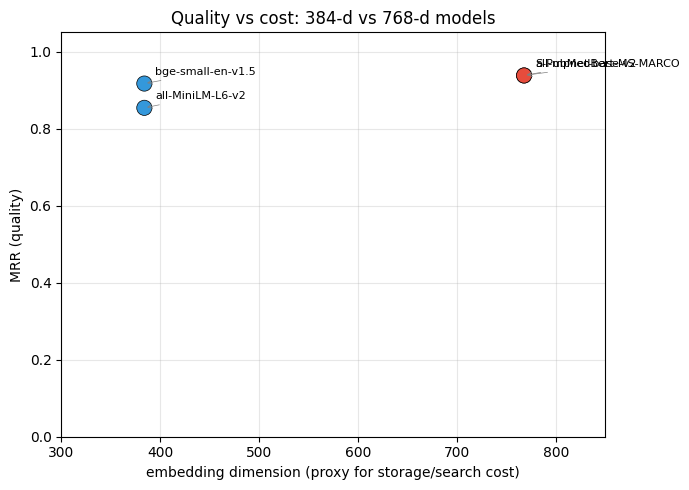

In [14]:
import matplotlib.pyplot as plt

if len(res_df):
    fig, ax = plt.subplots(figsize=(7, 5))
    # Color by dimension family
    colors = ["#3498db" if d == 384 else "#e74c3c" for d in res_df["dim"]]
    ax.scatter(
        res_df["dim"],
        res_df["MRR"],
        s=120,
        c=colors,
        edgecolors="black",
        linewidth=0.5,
        zorder=3,
    )
    for _, r in res_df.iterrows():
        ax.annotate(
            r["model"],
            (r["dim"], r["MRR"]),
            textcoords="offset points",
            xytext=(8, 6),
            fontsize=8,
            arrowprops=dict(arrowstyle="->", color="gray", lw=0.5),
        )
    ax.set_xlabel("embedding dimension (proxy for storage/search cost)")
    ax.set_ylabel("MRR (quality)")
    ax.set_title("Quality vs cost: 384-d vs 768-d models")
    ax.set_xlim(300, 850)
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 6. Synthesis: putting it all together

You now have a **complete embedding evaluation workflow** that you can reuse
on your own data:

1. **Define your dataset** — queries + labeled relevant documents (even 10–50
   queries gives directional signal).
2. **Encode and rank** — the `embed → cosine → sort` pipeline is model-agnostic.
3. **Compute metrics** — recall@k, MRR, MAP, NDCG with the functions above.
4. **Inspect failures** — the hard-negative analysis and per-query breakdown
   reveal *why* a model fails, not just that it does.
5. **Choose trade-offs** — the dimension-vs-MRR plot grounds your decision in
   data, not marketing.

**Next steps:** If you're building a RAG system, move to the Chapter 4
notebooks on retrieval and reranking. If you want to explore domain-specific
embedders, try the Chapter 2 Embeddings and Tokenizers notebook.

> **Remember:** the best embedding model is the one that performs best on
> *your* data, measured by *your* evaluation harness. This notebook gives you
> that harness — use it.

## Limitations & safety
- This retrieval set is **tiny and synthetic** — use it to learn the method, not to draw conclusions.
  Real evaluation needs hundreds of queries with statistical significance testing.
- With 4 models × 8 queries, MRR differences of < 0.1 are noise. Look for *directionally consistent*
  patterns: does the biomedical specialist beat the general models on q1/q7 (both CML drugs)?
- Hard negatives reveal what models *don't* understand — a model may get q1 right
  but rank d9 much higher than d10, showing partial discrimination.
- Hosted embeddings change over time; pin model versions for reproducibility.
- A model can win recall@1 yet still retrieve near-duplicates or leaky text; always inspect failures.

## Cleanup
Release models and free memory.


---
### Further Reading

| Notebook | Relevance |
|----------|-----------|
| **Chapter 2 Embeddings and Tokenizers** | SMILES/SELFIES embeddings and comparative analysis |
| **Chapter 4 RAG Evaluation** | Full RAG evaluation harness including citation validity |
| **Chapter 4 Hybrid Retrieval and Reranking** | BM25 + vector fusion with reranking |


In [15]:
import gc

try:
    del m
except Exception:
    pass
gc.collect()
print("🧹 embedding models released")

🧹 embedding models released


## Exercises

1. Why can a model with a higher MTEB score underperform on your biomedical retrieval set?
   <details><summary>Hint</summary>Domain shift: gene symbols, drug names, and assay jargon are rare in general web corpora used for benchmark training.</details>
2. What does a top-1 failure where the model returns a *chemically similar but wrong* doc tell you?
   <details><summary>Hint</summary>The embedding captures semantic similarity but not the precise entity relation; consider a cross-encoder reranker.</details>
3. When is a smaller, lower-quality embedding the right choice?
   <details><summary>Hint</summary>At very large scale or tight latency budgets, a cheaper first-stage retriever + reranker can beat one expensive model.</details>

### Task A — Explain the 2×2 pattern
After running all 4 models, answer: (a) does bge-small (384-d) beat MiniLM (384-d)? If so, what does that tell you
about training objectives vs dimension? (b) does S-PubMedBert (768-d, biomedical) beat mpnet (768-d, general)?
What does that say about domain adaptation?

### Task B — Add a fifth model
Add a model from a different family: try `BAAI/bge-base-en-v1.5` (768-d, top MTEB generalist) or
`sentence-transformers/all-distilroberta-v1` (768-d, distilled). Does it fit the pattern you observed?

### Task C — Reranking
Take the top-5 from the best bi-encoder and re-score with a cross-encoder (`cross-encoder/ms-marco-MiniLM-L-6-v2`).
Measure the recall@1 improvement. Does the reranker fix the hard-negative mistakes?

### Task D — Build a real mini-set
Write 10 queries + relevant docs from a paper you know. Include at least 2 hard negatives. Re-run `evaluate`.
Which failure modes appear that the synthetic set missed?

### Task E — Cost model
For a 1M-document corpus, estimate storage (float32) and brute-force search cost for 384-d vs 768-d.
At what QPS (queries per second) does the smaller model become the only viable choice?
